# No-currents ablation: route comparison

Compare elite routes from baseline (all forcing) vs no-currents (waves+wind only).
Focus: do Jan (wave-dominated) routes look similar? If yes, cost differences reflect value of current knowledge.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import warnings

from experiment_params import FORCING_BASELINE
from load_results import (
    load_results,
    filter_kinked_routes,
    get_journey_params_df,
    get_elite_df,
)
from ship_routing.core.data import load_currents, load_waves, load_winds
from ship_routing.core.hashable_dataset import make_hashable
from ship_routing.core.routes import Route, WayPoint
from ship_routing.core.config import SHIP_DEFAULT, PHYSICS_DEFAULT

sns.set_theme(style="whitegrid", context="paper", font_scale=1.75)
warnings.filterwarnings("ignore")

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

## Load baseline and no-currents results

In [2]:
result_dir = Path("../results")

baseline_files = sorted(result_dir.glob("cost_sub*.msgpack"))
nc_files = sorted(result_dir.glob("cost_no_currents_sub*.msgpack"))

print(f"Baseline files: {[f.name for f in baseline_files]}")
print(f"No-currents files: {[f.name for f in nc_files]}")

Baseline files: ['cost_sub01_20260211_163739.msgpack', 'cost_sub01_20260625_102518.msgpack', 'cost_sub01_20260625_163025.msgpack', 'cost_sub02_20260211_164705.msgpack', 'cost_sub02_20260625_102517.msgpack', 'cost_sub02_20260625_163025.msgpack']
No-currents files: ['cost_no_currents_sub01_20260212_103623.msgpack', 'cost_no_currents_sub01_20260625_102517.msgpack', 'cost_no_currents_sub01_20260625_163025.msgpack', 'cost_no_currents_sub02_20260212_103623.msgpack', 'cost_no_currents_sub02_20260625_102517.msgpack', 'cost_no_currents_sub02_20260625_163025.msgpack']


In [3]:
rr_base = load_results(baseline_files)
rr_base = filter_kinked_routes(rr_base)
print(f"Baseline: {len(rr_base)} clean routes")

records:   0%|          | 0/1762 [00:00<?, ?it/s]

230/1762 routes removed (max turning angle > 60.0°)
Baseline: 1532 clean routes


In [4]:
rr_nc = load_results(nc_files)
rr_nc = filter_kinked_routes(rr_nc)
print(f"No-currents: {len(rr_nc)} clean routes")

records:   0%|          | 0/1778 [00:00<?, ?it/s]

253/1778 routes removed (max turning angle > 60.0°)
No-currents: 1525 clean routes


## Extract best routes per case

In [5]:
def build_case_df(rr_dict):
    """Build merged journey+elite DF with month/speed columns."""
    journey_df = get_journey_params_df(rr_dict)
    elite_df = get_elite_df(rr_dict)
    elite_best = elite_df[elite_df.n_elite == 0]
    df = journey_df.join(elite_best)
    df["month"] = pd.to_datetime(df.journey_time_start.astype(str)).dt.month
    df["speed"] = df.journey_speed_knots.astype(float)
    return df


def all_routes_for_case(df, rr_dict, case):
    """Get all replica routes for a given case, sorted by cost."""
    mask = (
        (df.journey_name == case["journey"])
        & (df.month == case["month"])
        & (df.speed == case["speed"])
    )
    sub = df[mask].sort_values("elite_cost_absolute")
    results = []
    for key, row in sub.iterrows():
        route = rr_dict[key].elite_population.members[0].route
        results.append({
            "key": key,
            "cost_TJ": row.elite_cost_absolute / 1e12,
            "route": route,
            "lons": [wp.lon for wp in route.way_points],
            "lats": [wp.lat for wp in route.way_points],
        })
    return results


def route_with_ns_time(route):
    """Convert route timestamps to ns precision for data lookup."""
    return Route(way_points=tuple(
        WayPoint(lon=wp.lon, lat=wp.lat, time=np.datetime64(wp.time, "ns"))
        for wp in route.way_points
    ))


CASES = [
    {"month": 1, "journey": "Atlantic_forward", "speed": 8.0, "label": "Jan E 8kn"},
    {"month": 1, "journey": "Atlantic_forward", "speed": 12.0, "label": "Jan E 12kn"},
    {"month": 1, "journey": "Atlantic_forward", "speed": 16.0, "label": "Jan E 16kn"},
    {"month": 1, "journey": "Atlantic_forward", "speed": 20.0, "label": "Jan E 20kn"},
    {"month": 1, "journey": "Atlantic_backward", "speed": 8.0, "label": "Jan W 8kn"},
    {"month": 1, "journey": "Atlantic_backward", "speed": 12.0, "label": "Jan W 12kn"},
    {"month": 1, "journey": "Atlantic_backward", "speed": 16.0, "label": "Jan W 16kn"},
    {"month": 1, "journey": "Atlantic_backward", "speed": 20.0, "label": "Jan W 20kn"},
    {"month": 8, "journey": "Atlantic_forward", "speed": 8.0, "label": "Aug E 8kn"},
    {"month": 8, "journey": "Atlantic_forward", "speed": 12.0, "label": "Aug E 12kn"},
    {"month": 8, "journey": "Atlantic_forward", "speed": 16.0, "label": "Aug E 16kn"},
    {"month": 8, "journey": "Atlantic_forward", "speed": 20.0, "label": "Aug E 20kn"},
    {"month": 8, "journey": "Atlantic_backward", "speed": 8.0, "label": "Aug W 8kn"},
    {"month": 8, "journey": "Atlantic_backward", "speed": 12.0, "label": "Aug W 12kn"},
    {"month": 8, "journey": "Atlantic_backward", "speed": 16.0, "label": "Aug W 16kn"},
    {"month": 8, "journey": "Atlantic_backward", "speed": 20.0, "label": "Aug W 20kn"},
]

CASE_LABELS = {c["label"]: c["label"].replace("Jan", "Jan 2021").replace("Aug", "Aug 2021") for c in CASES}

In [6]:
df_base = build_case_df(rr_base)
df_nc = build_case_df(rr_nc)

# Collect all replicas per case for median analysis
all_routes = {}
for case in CASES:
    base_all = all_routes_for_case(df_base, rr_base, case)
    nc_all = all_routes_for_case(df_nc, rr_nc, case)
    all_routes[case["label"]] = {"baseline": base_all, "no_currents": nc_all}

    base_costs = [r["cost_TJ"] for r in base_all]
    nc_costs = [r["cost_TJ"] for r in nc_all]
    print(f"{case['label']:14s}  base: {len(base_all)} replicas, "
          f"median={np.nanmedian(base_costs):.3f} TJ  |  "
          f"nc: {len(nc_all)} replicas, median={np.nanmedian(nc_costs):.3f} TJ")

# Best routes for map display (lowest cost, including kinky routes)
map_routes = {}
for case in CASES:
    label = case["label"]
    for src_list, src_name in [(all_routes[label]["baseline"], "baseline"),
                               (all_routes[label]["no_currents"], "no_currents")]:
        if label not in map_routes:
            map_routes[label] = {}
        map_routes[label][src_name] = src_list[0]  # already sorted by cost
        map_routes[label][src_name]["month"] = case["month"]

elite:   0%|          | 0/1532 [00:00<?, ?it/s]

elite:   0%|          | 0/1525 [00:00<?, ?it/s]

Jan E 8kn       base: 8 replicas, median=8.891 TJ  |  nc: 8 replicas, median=8.972 TJ
Jan E 12kn      base: 9 replicas, median=11.877 TJ  |  nc: 7 replicas, median=12.402 TJ
Jan E 16kn      base: 8 replicas, median=13.444 TJ  |  nc: 9 replicas, median=13.850 TJ
Jan E 20kn      base: 9 replicas, median=32.736 TJ  |  nc: 10 replicas, median=31.951 TJ
Jan W 8kn       base: 9 replicas, median=10.754 TJ  |  nc: 14 replicas, median=10.286 TJ
Jan W 12kn      base: 18 replicas, median=9.437 TJ  |  nc: 21 replicas, median=9.100 TJ
Jan W 16kn      base: 16 replicas, median=14.068 TJ  |  nc: 14 replicas, median=13.783 TJ
Jan W 20kn      base: 10 replicas, median=22.040 TJ  |  nc: 10 replicas, median=21.730 TJ
Aug E 8kn       base: 17 replicas, median=2.041 TJ  |  nc: 15 replicas, median=2.614 TJ
Aug E 12kn      base: 30 replicas, median=4.945 TJ  |  nc: 26 replicas, median=5.794 TJ
Aug E 16kn      base: 17 replicas, median=7.229 TJ  |  nc: 18 replicas, median=8.039 TJ
Aug E 20kn      base: 9 repl

## Route comparison maps

One map per month. Color = direction + speed, solid = baseline, dashed = no-currents.

<cell_type>markdown</cell_type>## Re-evaluate all replicas with full forcing

Use **median cost across replicas** (not best) for a fair comparison.
The baseline stored costs are already correct (optimizer used currents).
NC routes need re-evaluation WITH currents to get actual ocean cost.

In [7]:
# Load forcing data for Jan and Aug
spatial_bounds = (-85, -5, 25, 60)
data_prefix = Path("..")

datasets = {}
for month, tstart, tend in [(1, "2021-01-01", "2021-02-01"), (8, "2021-08-01", "2021-09-01")]:
    print(f"Loading month {month}...")
    currents = load_currents(
        data_prefix / FORCING_BASELINE.currents_path,
        time_start=np.datetime64(tstart), time_end=np.datetime64(tend),
        engine=FORCING_BASELINE.engine, spatial_bounds=spatial_bounds,
        load_eagerly=True,
    )
    n_nan = int(currents.uo.isnull().sum())
    n_total = currents.uo.size
    currents = make_hashable(currents.fillna(0))
    print(f"  currents: filled {n_nan}/{n_total} NaN cells ({n_nan/n_total*100:.1f}%) with 0")

    datasets[month] = {
        "currents": currents,
        "waves": load_waves(
            data_prefix / FORCING_BASELINE.waves_path,
            time_start=np.datetime64(tstart), time_end=np.datetime64(tend),
            engine=FORCING_BASELINE.engine, spatial_bounds=spatial_bounds,
            load_eagerly=True,
        ),
        "winds": load_winds(
            data_prefix / FORCING_BASELINE.winds_path,
            time_start=np.datetime64(tstart), time_end=np.datetime64(tend),
            engine=FORCING_BASELINE.engine, spatial_bounds=spatial_bounds,
            load_eagerly=True,
        ),
    }
print("Done.")

Loading month 1...


  currents: filled 2702601/13351173 NaN cells (20.2%) with 0


Loading month 8...
  currents: filled 2784498/13755754 NaN cells (20.2%) with 0


Done.


In [8]:
# Re-evaluate ALL nc replicas with full forcing.
# Baseline stored costs are already correct (optimizer used currents).
from tqdm.auto import tqdm

reeval_rows = []
for case in CASES:
    label = case["label"]
    month = case["month"]
    ds = datasets[month]

    # Baseline: use stored costs directly
    for r in all_routes[label]["baseline"]:
        reeval_rows.append({
            "case": label, "source": "baseline", "key": r["key"],
            "stored_TJ": r["cost_TJ"], "cost_with_currents_TJ": r["cost_TJ"],
        })

    # NC: re-evaluate each replica with currents
    for r in tqdm(all_routes[label]["no_currents"],
                  desc=f"nc {label}", leave=False):
        nc_route = route_with_ns_time(r["route"])

        nc_cost_with = nc_route.cost_through(
            current_data_set=ds["currents"], wind_data_set=ds["winds"],
            wave_data_set=ds["waves"], ship=SHIP_DEFAULT, physics=PHYSICS_DEFAULT,
        )
        nc_cost_without = nc_route.cost_through(
            current_data_set=None, wind_data_set=ds["winds"],
            wave_data_set=ds["waves"], ship=SHIP_DEFAULT, physics=PHYSICS_DEFAULT,
        )

        reeval_rows.append({
            "case": label, "source": "no_currents", "key": r["key"],
            "stored_TJ": r["cost_TJ"],
            "cost_with_currents_TJ": nc_cost_with / 1e12,
            "cost_without_currents_TJ": nc_cost_without / 1e12,
        })

reeval_all = pd.DataFrame(reeval_rows)

# Validation: nc stored cost should match re-eval without currents
nc_rows = reeval_all[reeval_all.source == "no_currents"]
nc_match = np.isclose(nc_rows.stored_TJ, nc_rows.cost_without_currents_TJ, rtol=1e-3)
print(f"NC validation: {nc_match.sum()}/{len(nc_match)} match stored costs")

# Any NaN in nc re-eval?
n_nan = reeval_all.cost_with_currents_TJ.isna().sum()
print(f"NaN in cost_with_currents: {n_nan}")

print(f"\nTotal re-evaluated: {len(reeval_all)} "
      f"({(reeval_all.source=='baseline').sum()} baseline, "
      f"{(reeval_all.source=='no_currents').sum()} nc)")

nc Jan E 8kn:   0%|          | 0/8 [00:00<?, ?it/s]

nc Jan E 12kn:   0%|          | 0/7 [00:00<?, ?it/s]

nc Jan E 16kn:   0%|          | 0/9 [00:00<?, ?it/s]

nc Jan E 20kn:   0%|          | 0/10 [00:00<?, ?it/s]

nc Jan W 8kn:   0%|          | 0/14 [00:00<?, ?it/s]

...

nc Aug W 8kn:   0%|          | 0/18 [00:00<?, ?it/s]

nc Aug W 12kn:   0%|          | 0/26 [00:00<?, ?it/s]

nc Aug W 16kn:   0%|          | 0/16 [00:00<?, ?it/s]

nc Aug W 20kn:   0%|          | 0/10 [00:00<?, ?it/s]

NC validation: 219/232 match stored costs
NaN in cost_with_currents: 6

Total re-evaluated: 457 (225 baseline, 232 nc)


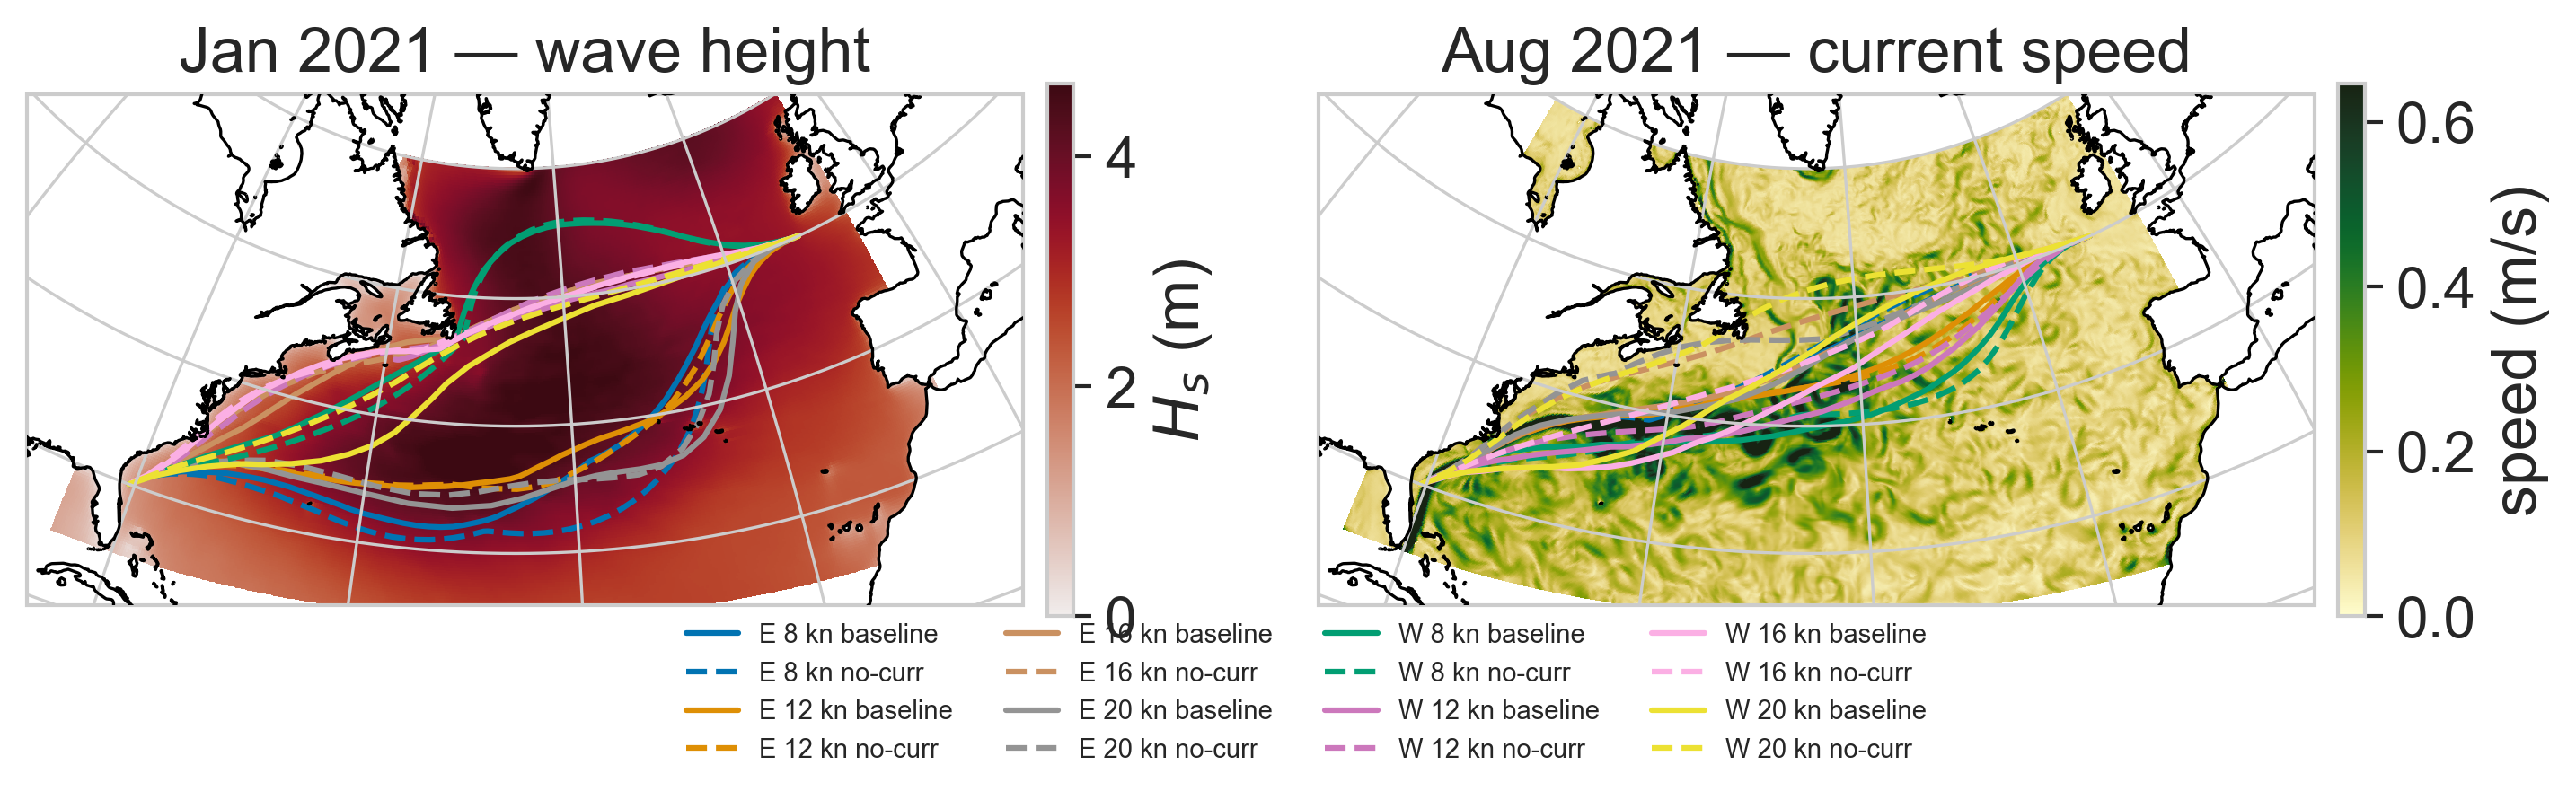

In [9]:
proj = ccrs.Stereographic(central_latitude=40.0, central_longitude=-45.75)
transform = ccrs.PlateCarree()

cb_palette = sns.color_palette("colorblind")
ROUTE_STYLES = {
    "E 8kn":  {"color": cb_palette[0], "label": "E 8 kn"},
    "E 12kn": {"color": cb_palette[1], "label": "E 12 kn"},
    "E 16kn": {"color": cb_palette[5], "label": "E 16 kn"},
    "E 20kn": {"color": cb_palette[7], "label": "E 20 kn"},
    "W 8kn":  {"color": cb_palette[2], "label": "W 8 kn"},
    "W 12kn": {"color": cb_palette[4], "label": "W 12 kn"},
    "W 16kn": {"color": cb_palette[6], "label": "W 16 kn"},
    "W 20kn": {"color": cb_palette[8], "label": "W 20 kn"},
}

MONTHS = [
    {"month": 1, "title": "Jan 2021 \u2014 wave height", "prefix": "Jan"},
    {"month": 8, "title": "Aug 2021 \u2014 current speed", "prefix": "Aug"},
]

# Time-mean fields
waves_jan = datasets[1]["waves"].wh.mean("time")
ds_curr_aug = datasets[8]["currents"]
curr_speed_aug = np.sqrt(ds_curr_aug.uo**2 + ds_curr_aug.vo**2).mean("time")

wave_vmax = float(waves_jan.quantile(0.98))
curr_vmax = float(curr_speed_aug.quantile(0.98))

fig, axes = plt.subplots(1, 2, subplot_kw={"projection": proj}, figsize=(10, 4))
fig.set_dpi(300)

for ax, minfo in zip(axes, MONTHS):
    if minfo["month"] == 1:
        im = waves_jan.plot(
            ax=ax, transform=transform, vmin=0, vmax=wave_vmax, extend="max",
            cmap=cmocean.cm.amp, rasterized=True, add_colorbar=False,
        )
        fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02, label="$H_s$ (m)")
    else:
        im = curr_speed_aug.plot(
            ax=ax, transform=transform, vmin=0, vmax=curr_vmax, extend="max",
            cmap=cmocean.cm.speed, rasterized=True, add_colorbar=False,
        )
        fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02, label="speed (m/s)")

    for style_key, style in ROUTE_STYLES.items():
        label = f"{minfo['prefix']} {style_key}"
        r = map_routes.get(label)
        if r is None:
            continue
        ax.plot(
            r["baseline"]["lons"], r["baseline"]["lats"],
            transform=transform, color=style["color"], lw=1.5,
            label=f"{style['label']} baseline",
        )
        nc = r.get("no_currents")
        if nc:
            ax.plot(
                nc["lons"], nc["lats"],
                transform=transform, color=style["color"], lw=1.5, ls="--",
                label=f"{style['label']} no-curr",
            )

    ax.add_feature(cfeature.LAND, facecolor="white", zorder=2)
    ax.coastlines(zorder=3)
    ax.gridlines(draw_labels=False)
    ax.set_extent([-85, -5, 20, 60])
    ax.set_title(minfo["title"])

# Legend at bottom, close to panels
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=7,
           bbox_to_anchor=(0.5, 0.12))

fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(FIG_DIR / "040_route_comparison.pdf", bbox_inches="tight", dpi=150)
plt.show()

## Current effect on ablation routes

For routes optimized without current knowledge: how much do currents change the actual energy cost?

- x = ablation route energy (what the optimizer saw, without currents)
- y = current effect = cost(with currents) - cost(without currents)
- Negative = currents help (reduce cost), positive = currents hinder

In [10]:
# Aggregate: median cost per case and source
medians = reeval_all.groupby(["case", "source"]).cost_with_currents_TJ.median().unstack()
medians.columns = ["baseline_median_TJ", "nc_median_TJ"]

# Also get nc median without currents (for current effect)
nc_median_without = (reeval_all[reeval_all.source == "no_currents"]
                     .groupby("case").cost_without_currents_TJ.median()
                     .rename("nc_median_without_TJ"))

reeval = medians.join(nc_median_without).reset_index()

# Value of current information: how much worse is the nc route in the real ocean?
reeval["value_of_info_TJ"] = reeval["nc_median_TJ"] - reeval["baseline_median_TJ"]
reeval["value_of_info_%"] = reeval["value_of_info_TJ"] / reeval["baseline_median_TJ"] * 100

# Current effect: how much do currents change the nc route cost?
reeval["current_effect_TJ"] = reeval["nc_median_TJ"] - reeval["nc_median_without_TJ"]
reeval["current_effect_%"] = reeval["current_effect_TJ"] / reeval["nc_median_without_TJ"] * 100

# Replica counts
n_replicas = reeval_all.groupby(["case", "source"]).size().unstack()
n_replicas.columns = ["n_base", "n_nc"]
reeval = reeval.merge(n_replicas.reset_index(), on="case")

# Direction+speed column matching map color scheme
reeval["dir_speed"] = reeval["case"].str.extract(r"([EW] \d+kn)")[0]
reeval["dir_speed"] = reeval["dir_speed"].str.replace("kn", " kn")
reeval["month"] = reeval["case"].str.extract(r"(Jan|Aug)")[0] + " 2021"

# Shared color palette matching ROUTE_STYLES from map
cb_palette = sns.color_palette("colorblind")
DIR_SPEED_PALETTE = {
    "E 8 kn":  cb_palette[0],
    "E 12 kn": cb_palette[1],
    "E 16 kn": cb_palette[5],
    "E 20 kn": cb_palette[7],
    "W 8 kn":  cb_palette[2],
    "W 12 kn": cb_palette[4],
    "W 16 kn": cb_palette[6],
    "W 20 kn": cb_palette[8],
}

reeval[["case", "dir_speed", "month", "n_base", "n_nc",
        "baseline_median_TJ", "nc_median_without_TJ", "nc_median_TJ",
        "value_of_info_TJ", "value_of_info_%",
        "current_effect_TJ", "current_effect_%"]]

,case,dir_speed,month,n_base,n_nc,baseline_median_TJ,nc_median_without_TJ,nc_median_TJ,value_of_info_TJ,value_of_info_%,current_effect_TJ,current_effect_%
0,Aug E 12kn,E 12 kn,Aug 2021,30,26,4.945074,5.794278,5.159952,0.214878,4.345299,-0.634326,-10.947451
1,Aug E 16kn,E 16 kn,Aug 2021,17,18,7.228549,8.038173,7.500711,0.272162,3.765101,-0.537462,-6.686376
2,Aug E 20kn,E 20 kn,Aug 2021,9,10,15.721601,16.529072,15.942026,0.220425,1.402054,-0.587046,-3.551599
3,Aug E 8kn,E 8 kn,Aug 2021,17,15,2.041286,2.612707,2.285397,0.244111,11.958705,-0.327310,-12.527615
4,Aug W 12kn,W 12 kn,Aug 2021,23,26,5.135892,4.993748,5.385096,0.249203,4.852190,0.391348,7.836760
5,Aug W 16kn,W 16 kn,Aug 2021,16,16,8.526235,8.316351,8.939032,0.412796,4.841484,0.622681,7.487431
6,Aug W 20kn,W 20 kn,Aug 2021,9,10,12.882625,12.460423,13.465149,0.582524,4.521783,1.004726,8.063337
7,Aug W 8kn,W 8 kn,Aug 2021,17,18,3.071703,3.022640,3.195714,0.124010,4.037188,0.173074,5.725926
8,Jan E 12kn,E 12 kn,Jan 2021,9,7,11.877347,12.400538,12.005972,0.128625,1.082943,-0.394566,-3.181845
9,Jan E 16kn,E 16 kn,Jan 2021,8,9,13.444012,13.854778,13.426191,-0.017821,-0.132560,-0.428587,-3.093424


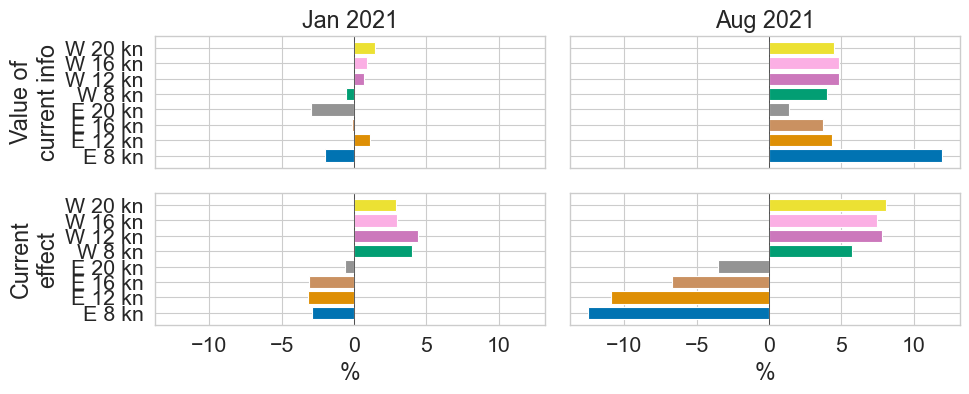

In [11]:
# Bar chart (%) — Jan / Aug side by side, color by dir+speed
dir_speed_order = ["E 8 kn", "E 12 kn", "E 16 kn", "E 20 kn", "W 8 kn", "W 12 kn", "W 16 kn", "W 20 kn"]
y = np.arange(len(dir_speed_order))

fig, axes = plt.subplots(2, 2, figsize=(10, 4.25), sharey=True, sharex=True)

for col, month_label in enumerate(["Jan 2021", "Aug 2021"]):
    sub = reeval[reeval.month == month_label].set_index("dir_speed").loc[dir_speed_order]
    colors = [DIR_SPEED_PALETTE[ds] for ds in dir_speed_order]

    axes[0, col].barh(y, sub["value_of_info_%"], color=colors)
    axes[0, col].axvline(0, color="k", lw=0.5)
    axes[0, col].set_title(month_label)
    axes[0, col].invert_yaxis()

    axes[1, col].barh(y, sub["current_effect_%"], color=colors)
    axes[1, col].axvline(0, color="k", lw=0.5)
    axes[1, col].invert_yaxis()

axes[0, 0].set_yticks(y)
axes[0, 0].set_yticklabels(dir_speed_order)
axes[0, 0].set_ylabel("Value of\ncurrent info")
axes[1, 0].set_ylabel("Current\neffect")
axes[1, 0].set_xlabel("%")
axes[1, 1].set_xlabel("%")

fig.tight_layout()
fig.savefig(FIG_DIR / "040_ablation_bars_pct.pdf", bbox_inches="tight")
plt.show()

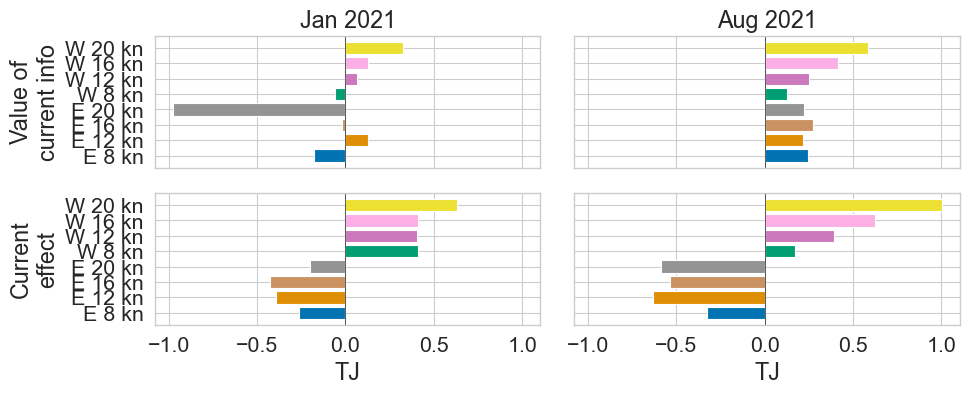

In [12]:
# Bar chart (TJ) — Jan / Aug side by side, color by dir+speed
fig, axes = plt.subplots(2, 2, figsize=(10, 4.25), sharey=True, sharex=True)

for col, month_label in enumerate(["Jan 2021", "Aug 2021"]):
    sub = reeval[reeval.month == month_label].set_index("dir_speed").loc[dir_speed_order]
    colors = [DIR_SPEED_PALETTE[ds] for ds in dir_speed_order]

    axes[0, col].barh(y, sub["value_of_info_TJ"], color=colors)
    axes[0, col].axvline(0, color="k", lw=0.5)
    axes[0, col].set_title(month_label)
    axes[0, col].invert_yaxis()

    axes[1, col].barh(y, sub["current_effect_TJ"], color=colors)
    axes[1, col].axvline(0, color="k", lw=0.5)
    axes[1, col].invert_yaxis()

axes[0, 0].set_yticks(y)
axes[0, 0].set_yticklabels(dir_speed_order)
axes[0, 0].set_ylabel("Value of\ncurrent info")
axes[1, 0].set_ylabel("Current\neffect")
axes[1, 0].set_xlabel("TJ")
axes[1, 1].set_xlabel("TJ")

fig.tight_layout()
fig.savefig(FIG_DIR / "040_ablation_bars_TJ.pdf", bbox_inches="tight")
plt.show()